In [101]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from torch.optim import SGD
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

from matplotlib import pyplot as plt

import warnings 

warnings.filterwarnings('ignore')

Regularization & Dropout
- Dropout
Observera följande kodsnutt.
dropout_layer = nn.Dropout(p=0.2)
input = torch.randn(1,10)
output = dropout_layer(input)
1) Vad tror du koden gör?
2) Vad får du för output om du kör koden ett par gånger? Does it make sense?
3) Anta att vi ändrar batch_size till 3. Hur ändrar vi i koden ovan?
4) Ändra batch_size till 3, och kör koden ett par gånger. Vad får du för output? Does it
make sense?

In [102]:
probability = 0.1

dropout_layer = nn.Dropout(p=probability)
input = torch.randn(1,10)

print("Input Tensor:")
print(input)

output = dropout_layer(input)

print("\nOutput Tensor after applying Dropout:")
print(output)

Input Tensor:
tensor([[-1.0840, -0.3879,  0.0427,  0.1024, -0.4361, -1.3300, -0.9961,  0.8310,
          0.6184,  0.2303]])

Output Tensor after applying Dropout:
tensor([[-0.0000, -0.4310,  0.0000,  0.0000, -0.4846, -1.4778, -1.1068,  0.0000,
          0.6871,  0.2559]])


In [103]:
probability = 0.2

dropout_layer = nn.Dropout(p=probability)
input = torch.randn(1,10)

print("Input Tensor:")
print(input)


output = dropout_layer(input)
print("\nOutput Tensor after applying Dropout:")
print(output)

for i, (input_tensor, output_tensor) in enumerate(zip(input[0], output[0])):
    print(f"\nNeuron {i}:")
    print(f"Input Tensor value: {input_tensor}")
    print(f"Output Tensor value: {output_tensor}")
    difference = output_tensor - input_tensor
    print(f"Difference: {difference}")
    difference_divided = difference / input_tensor if input_tensor != 0 else 'undefined (input is zero)'
    print(f"Difference divided by input: {difference_divided}")
    print(f"Input multiplied by 1 + diff: {input_tensor * (1 + difference_divided if input_tensor != 0 else 0)}")
    print(f"Input multiplied by (1 + p): {input_tensor * (1 + probability)}")

Input Tensor:
tensor([[ 0.2774,  1.4542, -0.9326,  1.1787, -0.1206,  0.0713, -0.1770,  0.3416,
         -0.2829,  1.3126]])

Output Tensor after applying Dropout:
tensor([[ 0.3467,  1.8177, -1.1657,  1.4733, -0.1507,  0.0892, -0.0000,  0.4270,
         -0.3536,  1.6408]])

Neuron 0:
Input Tensor value: 0.27739137411117554
Output Tensor value: 0.3467392325401306
Difference: 0.06934785842895508
Difference divided by input: 0.2500000596046448
Input multiplied by 1 + diff: 0.3467392325401306
Input multiplied by (1 + p): 0.33286964893341064

Neuron 1:
Input Tensor value: 1.4541586637496948
Output Tensor value: 1.817698359489441
Difference: 0.3635396957397461
Difference divided by input: 0.2500000298023224
Input multiplied by 1 + diff: 1.817698359489441
Input multiplied by (1 + p): 1.7449904680252075

Neuron 2:
Input Tensor value: -0.9325692057609558
Output Tensor value: -1.165711522102356
Difference: -0.23314231634140015
Difference divided by input: 0.2500000298023224
Input multiplied by 1 

### 1) What does the above code do?

It creates one input layer with 10 neurons with 10 random floats.
The input is fed into a dropout layer with a certain probablility. In this exercise it was originally 0.2. This means that the dropout layer applies a 20% probablity that each input will be zeroed in the output. The survivingneurons are multiplied by $\frac{1}{1 - p}$. The surviving neurons need to be scaled up so that the total contribution of all neurons remains the same despite some neurons dropping out.
This because we need to preserve the total network signal between training and inference. Dropout isn't used during inference, it's just a tool used in training. If we use weights trained with dropouts in the neural network, the weights won't give the same signal strenght during inference.

### 2 ) What output do you get if you run the code a few times? Does it make sense?

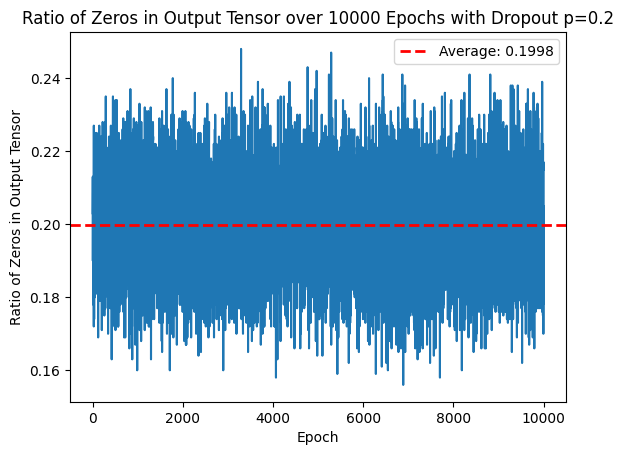

Average ratio of zeros over 10000 epochs: 0.19975199999999999


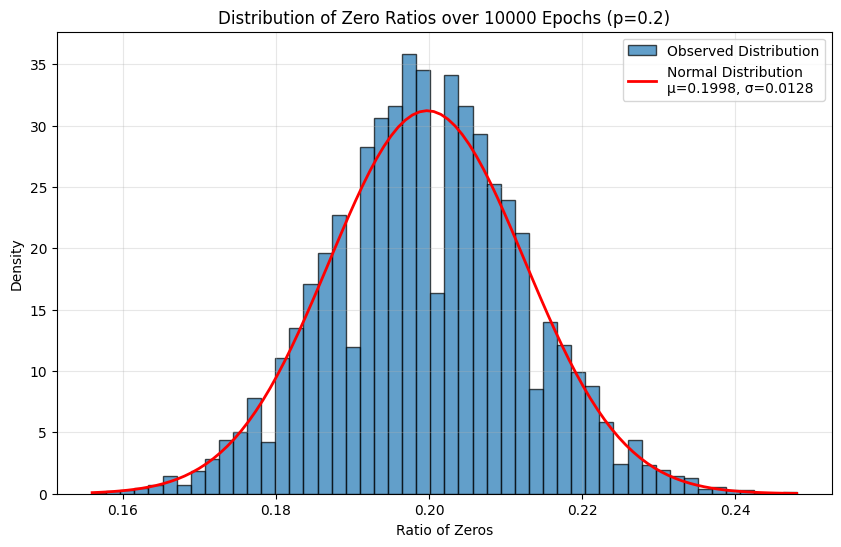

Mean: 0.1998
Standard deviation: 0.0128
Expected ratio (p): 0.2


In [104]:
probability = 0.2
epochs = 10000
num_neurons = 1000

dropout_layer = nn.Dropout(p=probability)
dropout_layer.train()  # Explicitly set to training mode

list_of_ratios = []

for epoch in range(epochs):

    input = torch.randn(1, num_neurons)

    output = dropout_layer(input)

    number_of_zeros = torch.sum(output == 0).item()
    ratio_of_zeros = number_of_zeros / output.numel()

    list_of_ratios.append(ratio_of_zeros)

plt.plot(list_of_ratios)
plt.axhline(y=np.mean(list_of_ratios), color='r', linestyle='--', linewidth=2, label=f'Average: {np.mean(list_of_ratios):.4f}')
plt.xlabel('Epoch')
plt.ylabel('Ratio of Zeros in Output Tensor')
plt.title(f'Ratio of Zeros in Output Tensor over {epochs} Epochs with Dropout p={probability}')
plt.legend()
plt.show()

average_ratio = np.mean(list_of_ratios)
print(f"Average ratio of zeros over {epochs} epochs: {average_ratio}")

# Plot histogram with normal distribution overlay
plt.figure(figsize=(10, 6))
plt.hist(list_of_ratios, bins=50, density=True, alpha=0.7, edgecolor='black', label='Observed Distribution')

# Fit a normal distribution to the data
mu = np.mean(list_of_ratios)
sigma = np.std(list_of_ratios)

# Plot the PDF of the normal distribution
x = np.linspace(min(list_of_ratios), max(list_of_ratios), 100)
plt.plot(x, (1/(sigma * np.sqrt(2*np.pi))) * np.exp(-0.5*((x-mu)/sigma)**2), 
         'r-', linewidth=2, label=f'Normal Distribution\nμ={mu:.4f}, σ={sigma:.4f}')

plt.xlabel('Ratio of Zeros')
plt.ylabel('Density')
plt.title(f'Distribution of Zero Ratios over {epochs} Epochs (p={probability})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Mean: {mu:.4f}")
print(f"Standard deviation: {sigma:.4f}")
print(f"Expected ratio (p): {probability}")

Each time we run the code some neurons might be zeroed, and some might not, according to our probability. If we run the code many times, we start to see that, the number of neurons zeroed, correspond to a normal distribution.

3) Anta att vi ändrar batch_size till 3. Hur ändrar vi i koden ovan?
4) Ändra batch_size till 3, och kör koden ett par gånger. Vad får du för output? Does it
make sense?

### 3) How do we update the code so we can set batch_size?

In [ ]:
probability = 0.2
batch_size = 32 
epochs = 10000
num_neurons = 1000  # Number of neurons in each input sample
num_samples = 1000  # Total samples in our fake dataset

dropout_layer = nn.Dropout(p=probability)
dropout_layer.train()

list_of_ratios = []

# NEW: Create dataset and dataloader (3 lines)
dataset = TensorDataset(torch.randn(num_samples, num_neurons), torch.zeros(num_samples))
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

for epoch in range(epochs):
    for input_batch, _ in dataloader:  # Changed this line
        
        output = dropout_layer(input_batch)  # Changed variable name
        
        number_of_zeros = torch.sum(output == 0).item()
        ratio_of_zeros = number_of_zeros / output.numel()
        
        list_of_ratios.append(ratio_of_zeros)

# Everything below stays EXACTLY the same
plt.plot(list_of_ratios)
plt.axhline(y=np.mean(list_of_ratios), color='r', linestyle='--', linewidth=2, 
            label=f'Average: {np.mean(list_of_ratios):.4f}')
plt.xlabel('Batch')  # Maybe change 'Epoch' to 'Batch' for accuracy
plt.ylabel('Ratio of Zeros in Output Tensor')
plt.title(f'Ratio of Zeros with Dropout p={probability}, Batch Size={batch_size}')
plt.legend()
plt.show()

average_ratio = np.mean(list_of_ratios)
print(f"Average ratio of zeros: {average_ratio}")

# Plot histogram with normal distribution overlay
plt.figure(figsize=(10, 6))
plt.hist(list_of_ratios, bins=50, density=True, alpha=0.7, edgecolor='black', 
         label='Observed Distribution')

mu = np.mean(list_of_ratios)
sigma = np.std(list_of_ratios)

x = np.linspace(min(list_of_ratios), max(list_of_ratios), 100)
plt.plot(x, (1/(sigma * np.sqrt(2*np.pi))) * np.exp(-0.5*((x-mu)/sigma)**2), 
         'r-', linewidth=2, label=f'Normal Distribution\nμ={mu:.4f}, σ={sigma:.4f}')

plt.xlabel('Ratio of Zeros')
plt.ylabel('Density')
plt.title(f'Distribution of Zero Ratios (p={probability}, batch_size={batch_size})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Mean: {mu:.4f}")
print(f"Standard deviation: {sigma:.4f}")
print(f"Expected ratio (p): {probability}")